In [1]:
import json
import os
from pathlib import Path
import sys

dirpath_root = Path().resolve().parents[2]
sys.path.append(str(dirpath_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from analysis.ou_tuning import netpyne_res_parse_utils as utils
from analysis.ou_tuning import sim_res_proc_utils as proc

In [2]:
# Experiment definition
exp_group = 'single_rxbkg_state1_mech1'
exp_name = 'net_newsec_ee_fade'

#exp_name_sub = 'exp_L4_unconn_t_6.0_10.0_wmult_0.25_ee_0.5_seed_1112'
exp_name_sub = 'exp_ctx_t_5.0_7.0_wmult_0.25_ee_0.5_seed_1113'

dirpath_cfg = dirpath_root / 'exp_configs' / exp_group / exp_name

# Load target firing rates
fpath_target = dirpath_cfg / 'target_state_1.csv'
df = pd.read_csv(fpath_target)
df = df.set_index('pop_name')

# Load simulation result
dirpath_res = dirpath_root / 'exp_results' / exp_group / exp_name / exp_name_sub
fpath_res = dirpath_res / f'{exp_name}_result.json'
with open(fpath_res, 'r') as fid:
    res = json.load(fid)

# Extract simulated rates from res and align with df
sim_rates = {pop: res['rates'].get(pop, float('nan'))
             for pop in df.index}

# Create comparison DataFrame
df_cmp = pd.DataFrame({
    'target_rate': df['target_rate'].round(2),
    'sim_rate': pd.Series(sim_rates).round(2)
})
df_cmp['diff'] = (df_cmp['sim_rate'] - df_cmp['target_rate']).round(2)
df_cmp = df_cmp[~np.isnan(df_cmp['sim_rate'])]
df_cmp


,target_rate,sim_rate,diff
NGF1,3.0,3.07,0.07
IT2,2.0,1.55,-0.45
PV2,12.0,15.88,3.88
SOM2,6.0,2.90,-3.10
VIP2,7.0,7.81,0.81
NGF2,1.0,1.27,0.27
IT3,2.0,2.04,0.04
PV3,12.0,13.73,1.73
SOM3,6.0,5.39,-0.61
VIP3,7.0,8.37,1.37


In [3]:
# Load sim result
fpath_pkl = dirpath_res / f'{exp_name}_data.pkl'
with open(fpath_pkl, 'rb') as fid:
    sim_res = pd.read_pickle(fid)

target_rates = df.to_dict()['target_rate']

--No graphics will be displayed.


In [11]:
PYR_POPS = ['IT2', 'IT3', 'ITP4', 'ITS4', 'IT5A', 'IT5B', 'IT6',
            'CT5A', 'CT5B', 'CT6', 'PT5B']
PV_POPS = ['PV2', 'PV3', 'PV4', 'PV5A', 'PV5B', 'PV6']
SOM_POPS = ['SOM2', 'SOM3', 'SOM4', 'SOM5A', 'SOM5B', 'SOM6']
VIP_POPS = ['VIP2', 'VIP3', 'VIP4', 'VIP5A', 'VIP5B', 'VIP6']
NGF_POPS = ['NGF1', 'NGF2', 'NGF3', 'NGF4', 'NGF5A', 'NGF5B', 'NGF6']

L2_POPS = ['IT2', 'PV2', 'SOM2', 'VIP2', 'NGF2']
L4_POPS = ['ITP4', 'ITS4', 'PV4', 'SOM4', 'VIP4', 'NGF4']

pop_groups = {'PYR': PYR_POPS, 'PV': PV_POPS, 'SOM': SOM_POPS,
              'VIP': VIP_POPS, 'NGF': NGF_POPS}

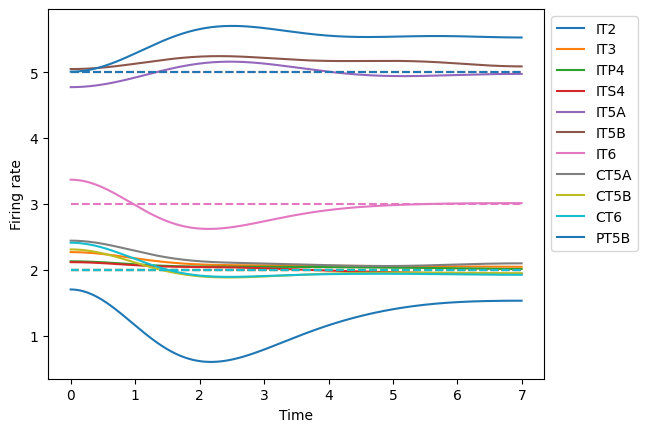

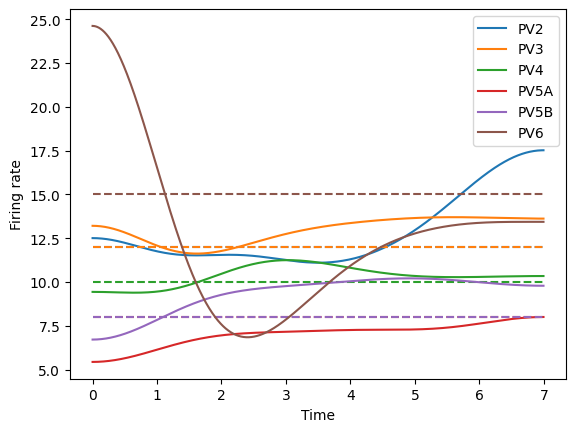

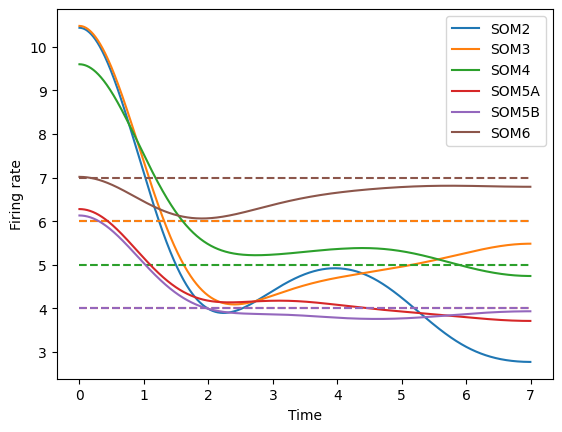

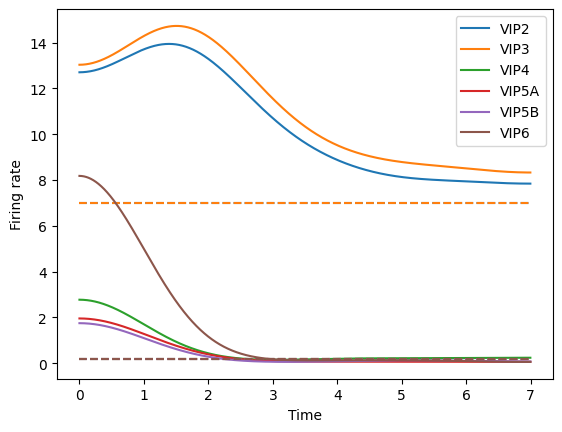

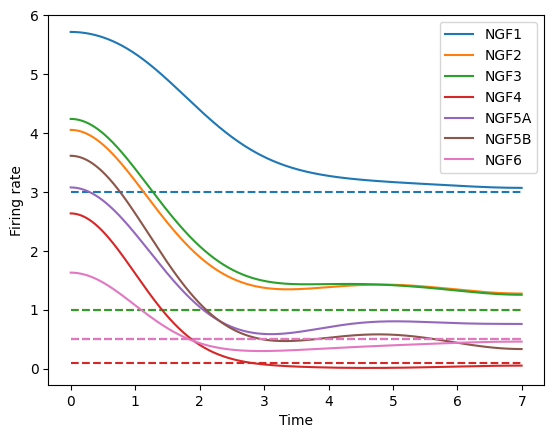

In [12]:
for pop_group_name, pops in pop_groups.items():
    #print(f'{pop_group_name}: {", ".join(pops)}')

    # Compute rate dynamics
    r_data = proc.calc_rate_dynamics(
        sim_res, t_limits=(0, None), tau_smooth=1, pops_used=pops)

    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    plt.figure()

    for n, pop in enumerate(pops):
        tt, rr = r_data[pop]
        r0 = target_rates[pop]
        col = colors[n % len(colors)]
        plt.plot(tt, rr, label=pop, color=col)
        plt.plot([tt[0], tt[-1]], [r0, r0], '--', color=col)

    plt.xlabel('Time')
    plt.ylabel('Firing rate')
    plt.legend(bbox_to_anchor=(1, 1))
    #plt.yscale('log')
    #plt.ylim(0.05, None)


In [9]:
# Experiment definition
exp_group = 'single_rxbkg_unconn_state1_mech1'
exp_name = 'net_newsec'

# exp_name_sub = 'exp_ctx_unconn_sm_21_t_6.0_10.0_wmult_0.25_ee_0.5'
exp_name_sub = 'exp_L2_unconn_sm_21_t_6.0_10.0_wmult_0.25_ee_0.5'
exp_name_sub_base = exp_name_sub

seeds = [1111, 1112, 1113, 1114, 1115]

dirpath_cfg = dirpath_root / 'exp_configs' / exp_group / exp_name

# Load target firing rates
fpath_target = dirpath_cfg / 'target_state_1.csv'
df = pd.read_csv(fpath_target)
df = df.set_index('pop_name')

# Create comparison DataFrame
df_cmp = pd.DataFrame({
    'target_rate': df['target_rate'].round(2)
})

# Load simulation result for each seed
for seed in seeds:
    exp_name_sub = f'{exp_name_sub_base}_seed_{seed}'
    dirpath_res = dirpath_root / 'exp_results' / exp_group / exp_name / exp_name_sub
    fpath_res = dirpath_res / f'{exp_name}_result.json'

    with open(fpath_res, 'r') as fid:
        res = json.load(fid)

    sim_rates = {
        pop: res['rates'].get(pop, float('nan'))
        for pop in df.index
    }

    sim_col = f'rate_{seed}'
    diff_col = f'diff_{seed}'

    df_cmp[sim_col] = pd.Series(sim_rates).round(2)
    df_cmp[diff_col] = (df_cmp[sim_col] - df_cmp['target_rate']).round(2)

# Keep only rows that have at least one simulated value
sim_cols = [f'rate_{seed}' for seed in seeds]
df_cmp = df_cmp[~df_cmp[sim_cols].isna().all(axis=1)]

df_cmp

diff_cols = sorted([c for c in df_cmp.columns if c.startswith('diff_')])
rate_cols = sorted([c for c in df_cmp.columns if c.startswith('rate_')])

#df_cmp = df_cmp[['target_rate'] + diff_cols + rate_cols]
df_cmp = df_cmp[diff_cols]
df_cmp


,diff_1111,diff_1112,diff_1113,diff_1114,diff_1115
pop_name,,,,,
IT2,-0.25,-0.76,-0.21,-0.07,-0.46
PV2,-2.92,-3.69,-0.60,0.54,0.67
SOM2,-2.70,-0.85,-2.45,-1.00,-0.40
VIP2,-1.47,-1.12,-1.23,-0.94,-0.38
NGF2,-0.05,-0.18,-0.02,-0.11,0.05


In [2]:
# Experiment definition
exp_group = 'batch_i_ou_full_state1_mech1_nosub_wmult_0.25'
exp_name = 'ee_nmda_fraction'
exp_name_sub = 'exp_t_20.0_25.0_ramp_-1_1000ms'

dirpath_cfg = dirpath_root / 'exp_configs' / exp_group / exp_name
dirpath_res = (dirpath_root / 'exp_results' / exp_group / exp_name /
               exp_name_sub / 'results')

# Load target firing rates
fpath_target = dirpath_cfg / 'target_state_1.csv'
df = pd.read_csv(fpath_target)
df = df.set_index('pop_name')

# Load simulation result
fpath_res = dirpath_res / 'result_00003_knmda_0.875.json'
with open(fpath_res, 'r') as fid:
    res = json.load(fid)

# Extract simulated rates from res and align with df
sim_rates = {pop: res['rates'][pop] for pop in df.index}

# Create comparison DataFrame
df_cmp = pd.DataFrame({
    'target_rate': df['target_rate'].round(2),
    'sim_rate': pd.Series(sim_rates).round(2)
})
df_cmp['diff'] = (df_cmp['sim_rate'] - df_cmp['target_rate']).round(2)
df_cmp


,target_rate,sim_rate,diff
NGF1,3.0,2.25,-0.75
IT2,2.0,1.41,-0.59
PV2,12.0,27.54,15.54
SOM2,6.0,14.52,8.52
VIP2,7.0,3.98,-3.02
NGF2,1.0,0.75,-0.25
IT3,2.0,2.68,0.68
PV3,12.0,34.41,22.41
SOM3,6.0,16.09,10.09
VIP3,7.0,3.79,-3.21


In [3]:
import pickle as pkl

fpath_conn = dirpath_root / 'conn' / 'conn.pkl'
with open(fpath_conn, 'rb') as fid:
    conn = pkl.load(fid)

conn


{'pmat': {'IT2': {'IT2': np.float64(0.1971161130784888),
   'IT3': np.float64(0.1971161130784888),
   'ITP4': np.float64(0.019711611307848882),
   'ITS4': np.float64(0.015829021201757432),
   'IT5A': np.float64(0.10225398365946607),
   'CT5A': np.float64(0.033035902413058274),
   'IT5B': np.float64(0.10225398365946607),
   'PT5B': np.float64(0.12899733323194185),
   'CT5B': np.float64(0.033035902413058274),
   'IT6': np.float64(0.0),
   'CT6': np.float64(0.0),
   'NGF1': np.float64(0.0),
   'PV2': np.float64(0.5406866917894705),
   'SOM2': np.float64(0.23449298047141015),
   'VIP2': np.float64(0.0657305390018572),
   'NGF2': np.float64(0.1352844118104289),
   'PV3': np.float64(0.5406866917894705),
   'SOM3': np.float64(0.23449298047141015),
   'VIP3': np.float64(0.0657305390018572),
   'NGF3': np.float64(0.1352844118104289),
   'PV4': np.float64(0.11361264662917989),
   'SOM4': np.float64(0.10693910647872001),
   'VIP4': np.float64(0.11361264662917989),
   'NGF4': np.float64(0.10693910

In [ ]:
# Experiment definition
exp_group = 'batch_i_ou_subnet_state1_mech1_nosub_wmult_0.25'
exp_name = 'full_model_ee_0.5_it6_pv6_split'
exp_name_sub = 'exp_t_3.0_5.0_wfrac_0_1'

dirpath_cfg = dirpath_root / 'exp_configs' / exp_group / exp_name
dirpath_res = (dirpath_root / 'exp_results' / exp_group / exp_name /
               exp_name_sub / 'results')

# Load target firing rates
fpath_target = dirpath_cfg / 'target_state_1.csv'
df = pd.read_csv(fpath_target)
df = df.set_index('pop_name')

# Load simulation results
json_files = sorted([f for f in os.listdir(dirpath_res) if f.endswith('.json')])
#print(json_files)
R = {}
wfrac_vals = []
for fname_res in json_files:
    wfrac = float(fname_res.split('_')[-1].replace('.json', ''))
    wfrac_vals.append(wfrac)
    ind = f'wfrac={wfrac}'
    R[ind] = {}
    with open(dirpath_res / fname_res, 'r') as fid:
        res_ = json.load(fid)
    for pop, r in res_['rates'].items():
        R[ind][pop] = r

# Extract simulated rates from R and align with df

rates_df = pd.DataFrame(R).reindex(index=df.index).sort_index(axis=1)
#print(rates_df.round(1))


,wfrac=0.0,wfrac=0.25,wfrac=0.5,wfrac=0.75,wfrac=1.0
pop_name,,,,,
NGF1,2.5,2.6,2.5,2.6,2.6
IT2,1.9,2.0,1.9,2.0,1.9
PV2,23.2,23.2,22.9,22.3,22.6
SOM2,10.8,10.2,10.4,9.7,9.5
VIP2,5.4,5.5,5.6,5.6,5.5
NGF2,0.7,0.8,0.7,0.8,0.7
IT3,2.2,2.2,2.2,2.2,2.2
PV3,19.9,19.5,19.0,18.6,18.8
SOM3,9.7,9.2,9.1,8.6,9.0


In [ ]:
# choose a default wfrac column to use for comparison (first sorted wfrac)
wfrac_selected = rates_df.columns[0]
sim_rates = rates_df[wfrac_selected]

# Create comparison DataFrame
df_cmp = pd.DataFrame({
    'target_rate': df['target_rate'].round(2),
    'sim_rate': pd.Series(sim_rates).round(2)
})
df_cmp['diff'] = (df_cmp['sim_rate'] - df_cmp['target_rate']).round(2)
df_cmp

In [24]:
# Experiment definition
exp_group = 'batch_i_ou_subnet_state1_mech1_nosub_wmult_0.25'
exp_name = 'full_model_ee_off_epv6_single_off'
exp_name_sub = 'exp_t_8.0_10.0'

dirpath_cfg = dirpath_root / 'exp_configs' / exp_group / exp_name
dirpath_res = (dirpath_root / 'exp_results' / exp_group / exp_name /
               exp_name_sub / 'results')

# Load target firing rates
fpath_target = dirpath_cfg / 'target_state_1.csv'
df = pd.read_csv(fpath_target)
df = df.set_index('pop_name')

# Load simulation results
json_files = sorted([f for f in os.listdir(dirpath_res) if f.endswith('.json')])
#print(json_files)
R = {}
for fname_res in json_files:
    pop_pre = fname_res.split('_')[-1].replace('.json', '')
    R[pop_pre] = {}
    with open(dirpath_res / fname_res, 'r') as fid:
        res_ = json.load(fid)
    for pop, r in res_['rates'].items():
        R[pop_pre][pop] = r

rr = {pop_pre: R_['PV6'] for pop_pre, R_ in R.items()}
pd.DataFrame(pd.Series(rr).round(1))

,0
IT2,36.8
IT3,38.0
ITS4,36.7
ITP4,38.8
IT5A,37.3
CT5A,38.0
IT5B,38.1
CT5B,37.5
PT5B,37.5
IT6,22.4


In [4]:
# Experiment definitions
exp_group = 'single_i_ou_subnet_state1_mech1_nosub_wmult_0.25'
exp_name_target = 'full_model_split_ee_conn'
exp_names_sub = {
    #'ctrl_off': (
    #    'full_model_split_ee_conn/exp_t_3.0_5.0_eefrac_0.5'),
    #'itpv_0.5_ctrl_off': (
    #    'full_model_split_ee_epv_conn/exp_t_8.0_10.0_ee_0.5_epv_0.5'),
    'ctrl_on_18': (
        'full_model_split_ee_conn/exp_t_21.0_25.0_eefrac_0.5_kmu_0.1_'
        'ksigma_0.0_tau_200_taus_1000_tc0_2000_tlock_18000_kci_0.0005_kcp_0.0'),
    'ctrl_on_15': (
        'full_model_split_ee_conn/exp_t_21.0_25.0_eefrac_0.5_kmu_0.1_'
        'ksigma_0.0_tau_200_taus_1000_tc0_2000_tlock_15000_kci_0.0005_kcp_0.0'),
    'ctrl_on_18_2500': (
        'full_model_split_ee_conn/exp_t_23.0_25.0_eefrac_0.5_kmu_0.1_'
        'ksigma_0.0_tau_200_taus_2500_tc0_2000_tlock_18000_kci_0.0005_kcp_0.0')
}

# Load target firing rates
dirpath_cfg = dirpath_root / 'exp_configs' / exp_group / exp_name_target
fpath_target = dirpath_cfg / 'target_state_1.csv'
df = pd.read_csv(fpath_target)
df = df.set_index('pop_name')

df_cmp = {'target': df['target_rate'].round(2)}

for label, exp_name_sub in exp_names_sub.items():
    # Load simulation results
    dirpath_res = dirpath_root / 'exp_results' / exp_group
    exp_name = exp_name_sub.split('/')[0]
    fpath_res = dirpath_res / exp_name_sub / f'{exp_name}_result.json'
    with open(fpath_res, 'r') as fid:
        res = json.load(fid)

    # Extract simulated rates from res and align with df
    sim_rates = {pop: res['rates'][pop] for pop in df.index}
    df_cmp[label] =  pd.Series(sim_rates).round(2)

# Create comparison DataFrame
df_cmp = pd.DataFrame(df_cmp)

# Calculate diffs
for label in exp_names_sub:
    df_cmp[f'{label}_err'] = (
        df_cmp[label] - df_cmp['target']).round(2)

df_cmp

,target,ctrl_on_18,ctrl_on_15,ctrl_on_18_2500,ctrl_on_18_err,ctrl_on_15_err,ctrl_on_18_2500_err
NGF1,3.0,3.06,3.05,2.99,0.06,0.05,-0.01
IT2,2.0,1.83,2.31,2.18,-0.17,0.31,0.18
PV2,12.0,5.52,9.19,7.35,-6.48,-2.81,-4.65
SOM2,6.0,1.15,8.05,2.20,-4.85,2.05,-3.80
VIP2,7.0,7.53,7.11,7.31,0.53,0.11,0.31
NGF2,1.0,1.20,0.95,1.27,0.20,-0.05,0.27
IT3,2.0,1.35,2.55,1.83,-0.65,0.55,-0.17
PV3,12.0,6.57,10.47,8.91,-5.43,-1.53,-3.09
SOM3,6.0,4.12,5.85,5.64,-1.88,-0.15,-0.36
VIP3,7.0,6.40,7.58,6.69,-0.60,0.58,-0.31
